In [22]:
# ============================================================
# PRODIGY INFOTECH
# DATA SCIENCE INTERNSHIP
# TASK-02
# Data Cleaning and Exploratory Data Analysis
# Dataset: Titanic
# ============================================================

# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Graph Style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("="*50)
print("Libraries Imported Successfully")
print("="*50)

Libraries Imported Successfully


In [23]:
import os

print("Current Working Directory:")
print(os.getcwd())

print("\nFiles Available:")
print(os.listdir())

# Load Dataset
df = pd.read_csv("train.csv")

print("\nDataset Loaded Successfully!")

Current Working Directory:
c:\Users\chandresh m\OneDrive\Documents\PRODIGY_DS_02

Files Available:
['.venv', 'cleaned_titanic.csv', 'images', 'PRODIGY_DS_02.ipynb', 'README.md', 'train.csv']

Dataset Loaded Successfully!


In [24]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [25]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 891
Columns : 12


In [26]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [28]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [29]:
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [30]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [31]:
missing = (df.isnull().sum()/len(df))*100

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing.round(2)
})

missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


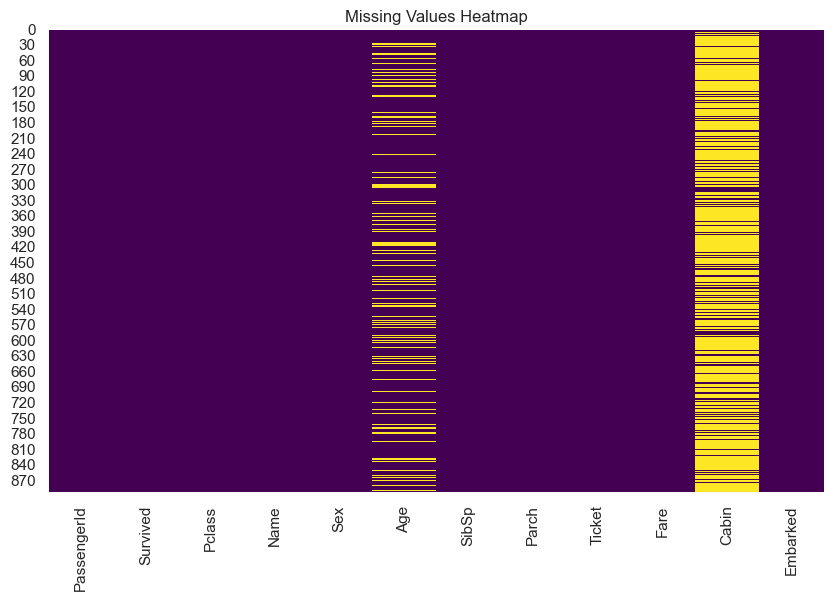

In [32]:
plt.figure(figsize=(10,6))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Missing Values Heatmap")
plt.show()

In [33]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [34]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [35]:
df.drop("Cabin", axis=1, inplace=True)

In [36]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [37]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 111.0 KB


In [39]:
df.to_csv("cleaned_titanic.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## Passenger Survival Distribution

This visualization shows the number of passengers who survived and those who did not survive.

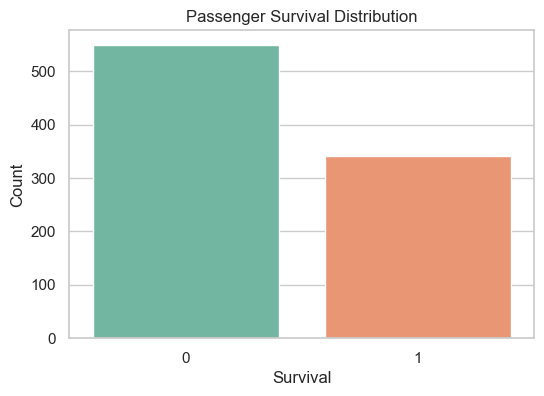

In [40]:
plt.figure(figsize=(6,4))

sns.countplot(x='Survived', data=df, palette='Set2')

plt.title("Passenger Survival Distribution")
plt.xlabel("Survival")
plt.ylabel("Count")

plt.savefig("images/survival_distribution.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

### Observation

- More passengers died than survived.
- The survival rate was comparatively lower.

## Gender Distribution

This graph displays the number of male and female passengers.

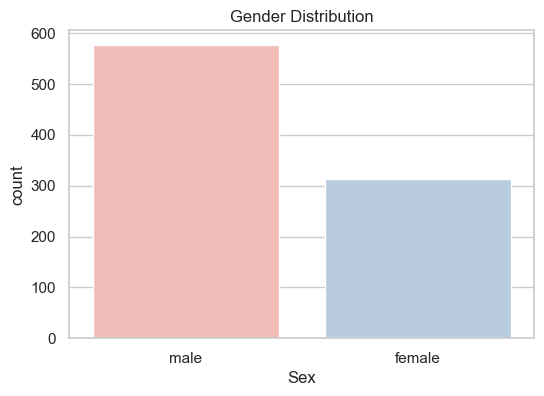

In [41]:
plt.figure(figsize=(6,4))

sns.countplot(x='Sex', data=df, palette='Pastel1')

plt.title("Gender Distribution")

plt.savefig("images/gender_distribution.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

### Observation

- Male passengers were more than female passengers.

## Passenger Class Distribution

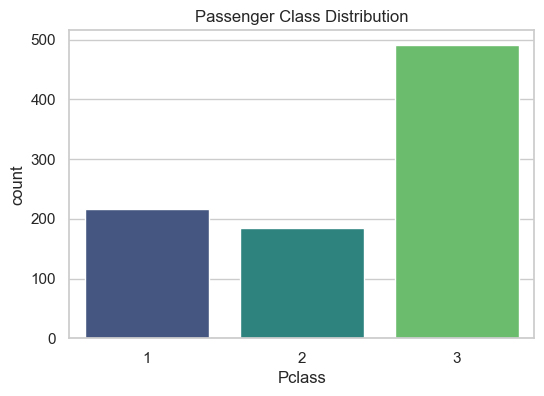

In [42]:
plt.figure(figsize=(6,4))

sns.countplot(x='Pclass', data=df, palette='viridis')

plt.title("Passenger Class Distribution")

plt.savefig("images/passenger_class_distribution.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

## Age Distribution

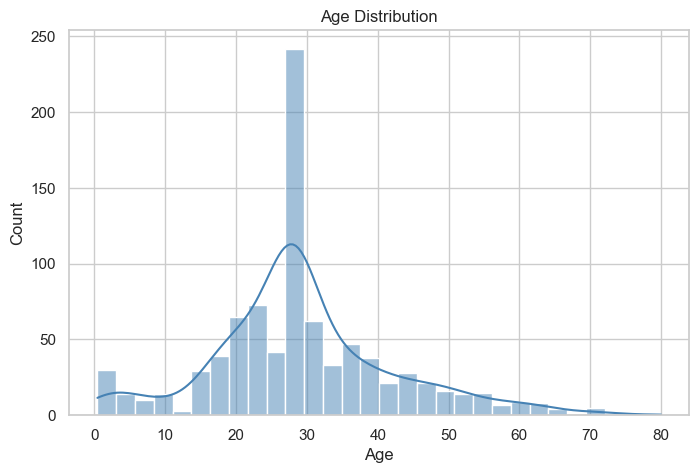

In [43]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'],
             bins=30,
             kde=True,
             color='steelblue')

plt.title("Age Distribution")

plt.savefig("images/age_distribution.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

## Fare Distribution

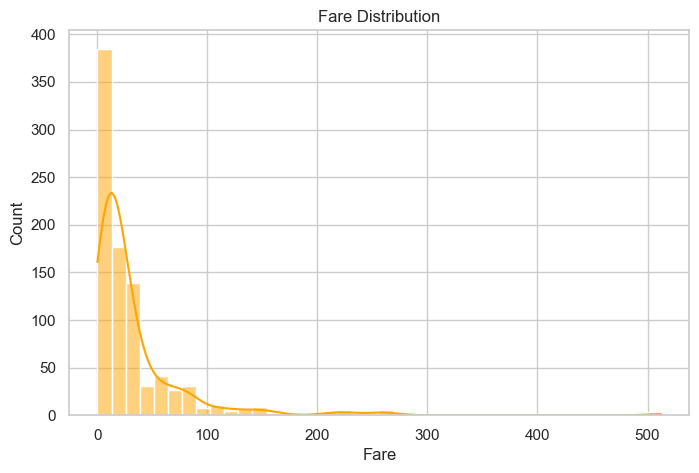

In [44]:
plt.figure(figsize=(8,5))

sns.histplot(df['Fare'],
             bins=40,
             kde=True,
             color='orange')

plt.title("Fare Distribution")

plt.savefig("images/fare_distribution.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

## Age Boxplot

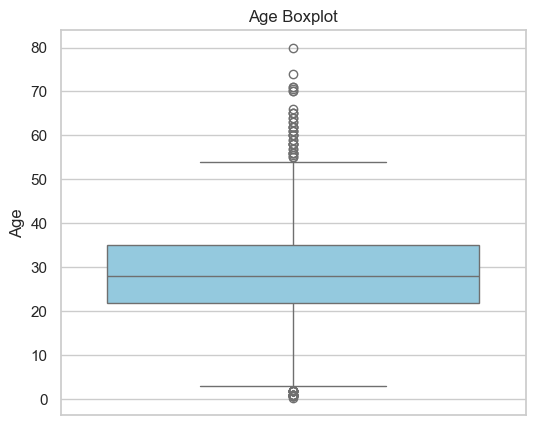

In [45]:
plt.figure(figsize=(6,5))

sns.boxplot(y=df['Age'],
            color='skyblue')

plt.title("Age Boxplot")

plt.savefig("images/age_boxplot.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

## Fare Boxplot

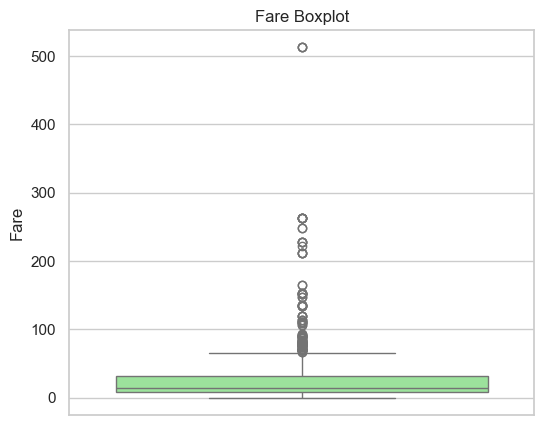

In [46]:
plt.figure(figsize=(6,5))

sns.boxplot(y=df['Fare'],
            color='lightgreen')

plt.title("Fare Boxplot")

plt.savefig("images/fare_boxplot.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

## Survival by Gender

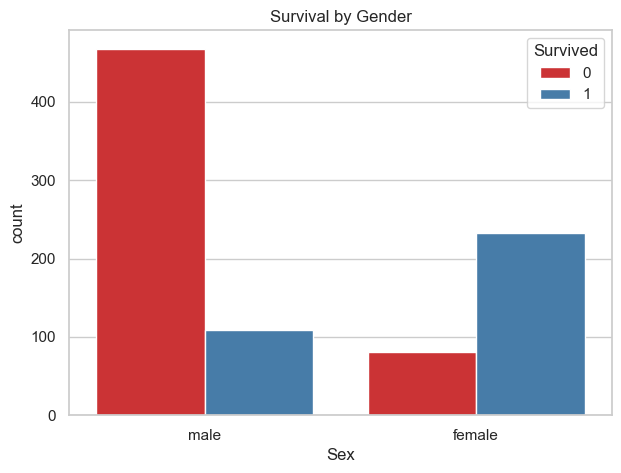

In [47]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Sex',
    hue='Survived',
    data=df,
    palette='Set1'
)

plt.title("Survival by Gender")

plt.savefig("images/survival_by_gender.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

## Survival by Passenger Class

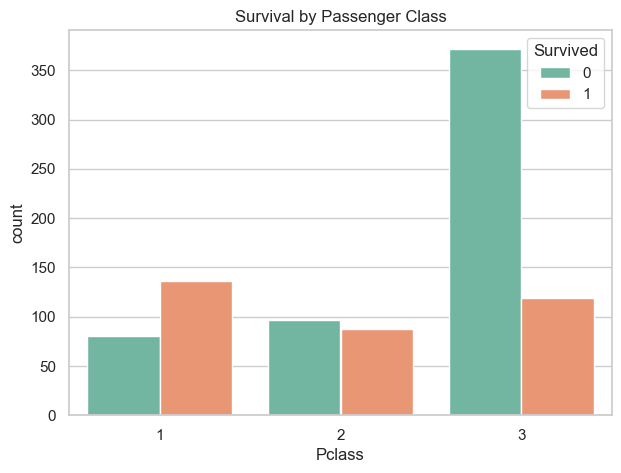

In [48]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Pclass',
    hue='Survived',
    data=df,
    palette='Set2'
)

plt.title("Survival by Passenger Class")

plt.savefig("images/survival_by_class.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

## Survival by Embarked

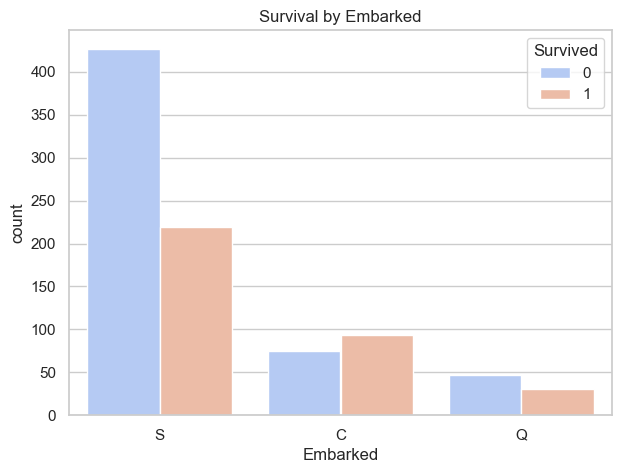

In [49]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Embarked',
    hue='Survived',
    data=df,
    palette='coolwarm'
)

plt.title("Survival by Embarked")

plt.savefig("images/survival_by_embarked.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

## Correlation Heatmap

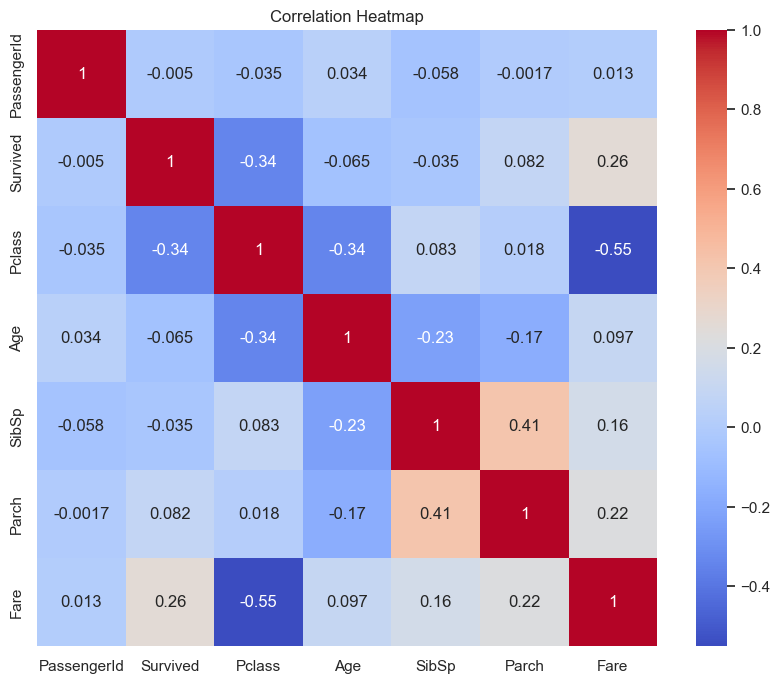

In [50]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.savefig("images/correlation_heatmap.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

## Pair Plot

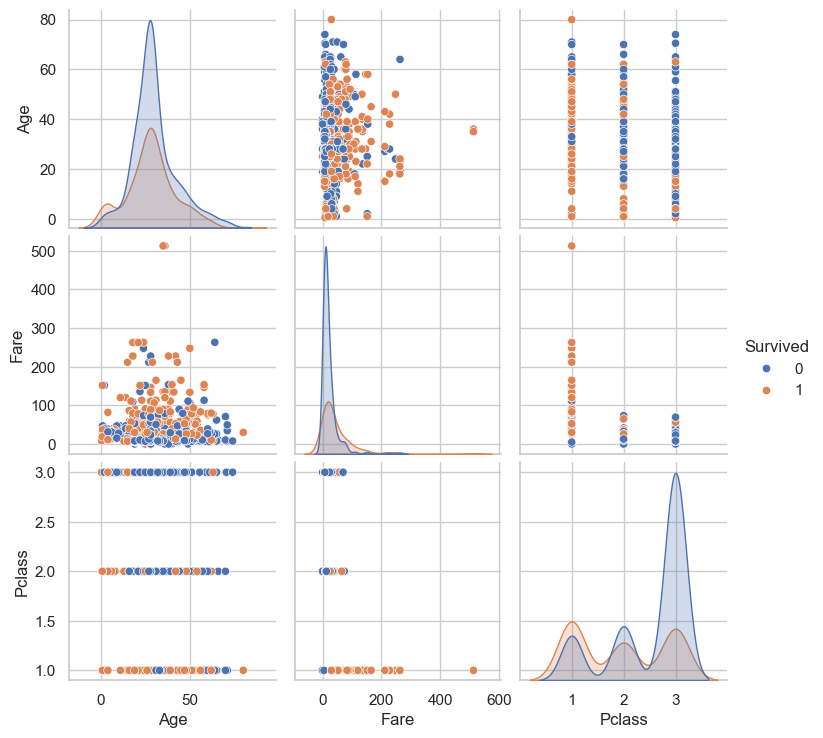

In [ ]:
pair = sns.pairplot(
    df[['Age','Fare','Pclass','Survived']],
    hue='Survived'
)

pair.savefig("images/pairplot.png", dpi=300)

plt.show()